# <center>Team 7 — Code Avengers </center>
## Labs + Prescription Medication Analysis
### Descriptive Analysis and Prescriptive Analysis

- **Primary dataset 1: Labs** — 2,008 patient-level rows and a wide range of physiologic/laboratory variables.
- **Primary dataset 2: Patient Prescriptions** — medication exposure records with multiple drugs per patient.
- **Supporting dataset: Demography** — used only for meaningful segmentation such as **age category, gender, BMI, weight and height**.

> **Important:** Prescriptive analysis here means **what the analytics team should review or investigate next**.  
> It does **not** prescribe medications or provide clinical treatment recommendations.

# Import, File Loading and Merging

In [22]:
# Optional one-time installation if your local Jupyter environment needs it:
# %pip install pandas numpy plotly scipy nbformat

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import spearmanr, mannwhitneyu


In [23]:
# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\__Final_Cleaned Dataset"
)

# Define CSV filenames
FILES = {
    "labs": "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    "prescriptions": "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    "demography": "Team7_CodeAvengers_Category1_DataCleaning_demography.csv",
}

# Read the cleaned datasets
labs = pd.read_csv(project_folder / FILES["labs"])
prescriptions = pd.read_csv(project_folder / FILES["prescriptions"])
demography = pd.read_csv(project_folder / FILES["demography"])

# Verify successful loading
print("Labs:", labs.shape)
print("Prescriptions:", prescriptions.shape)
print("Demography:", demography.shape)

Labs: (2008, 107)
Prescriptions: (15362, 2)
Demography: (2008, 7)


In [24]:
# Validate patient-level uniqueness before merging.
for name, df in {"labs": labs, "demography": demography}.items():
    print("\t")
    print(
        f"{name:12s} rows={len(df):,} | "
        f"unique patients={df['inpatient_number'].nunique():,} | "
        f"duplicate patient IDs={df['inpatient_number'].duplicated().sum():,}"
    )
print("\t")
print(
    f"prescriptions rows={len(prescriptions):,} | "
    f"unique patients={prescriptions['inpatient_number'].nunique():,} | "
    f"unique drug names={prescriptions['drug_name'].nunique():,}"
)

# Clean drug-name whitespace only; do not change clinical content.
rx = prescriptions.copy()
rx["drug_name"] = rx["drug_name"].astype(str).str.strip()

# Aggregate prescriptions BEFORE patient-level merge to avoid multiplying lab rows.
rx_summary = (
    rx.groupby("inpatient_number")
      .agg(
          prescription_rows=("drug_name", "size"),
          unique_medication_count=("drug_name", "nunique")
      )
      .reset_index()
)

patient = (
    labs
    .merge(demography, on="inpatient_number", how="left", validate="one_to_one")
    .merge(rx_summary, on="inpatient_number", how="left", validate="one_to_one")
)

patient[["prescription_rows", "unique_medication_count"]] = (
    patient[["prescription_rows", "unique_medication_count"]].fillna(0)
)

AGE_ORDER = ["21-29", "29-39", "39-49", "49-59", "59-69", "69-79", "79-89", "89-110"]
AGE_MIDPOINT = {
    "21-29": 25, "29-39": 34, "39-49": 44, "49-59": 54,
    "59-69": 64, "69-79": 74, "79-89": 84, "89-110": 99.5
}

patient["agecat"] = pd.Categorical(patient["agecat"], categories=AGE_ORDER, ordered=True)
patient["age_midpoint"] = patient["agecat"].astype(str).map(AGE_MIDPOINT)

print("\n Final patient-level analytical dataset:", patient.shape)
print("\n Unique patients:", patient["inpatient_number"].nunique())

	
labs         rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
demography   rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
prescriptions rows=15,362 | unique patients=2,007 | unique drug names=25

 Final patient-level analytical dataset: (2008, 116)

 Unique patients: 2008


# <center>PRESCRIPTIVE ANALYSIS </center>

In [25]:
ID, AGE, SEX = "inpatient_number", "agecat", "gender"
MIN_GROUP_N, MIN_PAIR_N = 10, 30
BG, FEMALE, MALE, TEAL = "#F2FBFD", "#B576A5", "#147D50", "#147D50"

for frame_name, frame, columns in [
    ("patient", patient, [ID, AGE, SEX]),
    ("labs", labs, [ID]),
]:
    absent = [c for c in columns if c not in frame.columns]
    if absent:
        raise KeyError(f"{frame_name} missing columns: {absent}")

# Use column names from the real labs CSV, not made-up marker names.
exclude_words = ("date", "time", "flag", "status", "label", "duration", "length", "index")
lab_candidates = []
for col in labs.columns:
    if col == ID or col not in patient.columns or any(w in col.lower() for w in exclude_words):
        continue
    numeric_values = pd.to_numeric(patient[col], errors="coerce")
    if numeric_values.notna().sum() >= 5 and numeric_values.nunique() >= 5:
        lab_candidates.append(col)

preferred_words = [
    "hemoglobin", "albumin", "troponin", "bnp", "natriuretic",
    "creatinine_enzymatic_method", "glomerular_filtration_rate",
    "urea", "glucose_blood_gas",
]
# Prioritize kidney-related laboratory biomarkers
kidney_markers = [
    "glomerular_filtration_rate",
    "creatinine_enzymatic_method",
    "urea"
]

# Identify other important laboratory biomarkers
preferred_words = [
    "hemoglobin",
    "albumin",
    "troponin",
    "bnp",
    "natriuretic",
    "glucose_blood_gas"
]

# Add available kidney markers first
MARKERS = [
    col for col in kidney_markers
    if col in lab_candidates
]

# Add other important biomarkers
for word in preferred_words:
    for col in lab_candidates:
        if word in col.lower() and col not in MARKERS:
            MARKERS.append(col)

# Add remaining laboratory biomarkers
MARKERS += [
    col for col in lab_candidates
    if col not in MARKERS
]

# Select the first 10 biomarkers
MARKERS = MARKERS[:10]

print("Selected Laboratory Biomarkers:")
print(MARKERS)
# One record per inpatient_number for analyses involving patient groups.
cols = [ID, AGE, SEX] + MARKERS
df = patient[cols].copy().dropna(subset=[ID])
for col in MARKERS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in [AGE, SEX]:
    df[col] = df[col].astype("string").str.strip().replace("", pd.NA)

raw_rows = len(df)
df = df.groupby(ID, as_index=False).agg({
    AGE: "first", SEX: "first", **{col: "median" for col in MARKERS}
})
print(f"Rows in merged patient data: {raw_rows:,}; distinct inpatient records: {len(df):,}")
if raw_rows > len(df):
    print("Repeated inpatient rows were combined using the median for each numeric lab.")

# Dataset-based comparison bounds: NOT clinical reference ranges.
BOUNDS = {
    col: (df[col].quantile(0.10), df[col].quantile(0.90))
    for col in MARKERS
}
flags = pd.DataFrame(index=df.index)
for col in MARKERS:
    low, high = BOUNDS[col]
    flags[col] = np.where(
        df[col].notna(),
        (df[col] < low) | (df[col] > high),
        np.nan
    ).astype(float)

print("Comparison method: below the 10th OR above the 90th cohort percentile.")

def style(fig, height=580):
    fig.update_layout(
        height=height, paper_bgcolor="white", plot_bgcolor=BG,
        font=dict(size=12), title_x=0.5
    )
    return fig

def group_text(row):
    return f"{row[AGE]} / {row[SEX]}"

Selected Laboratory Biomarkers:
['glomerular_filtration_rate', 'creatinine_enzymatic_method', 'urea', 'mean_hemoglobin_volume', 'mean_hemoglobin_concentration', 'hemoglobin', 'methemoglobin', 'reduced_hemoglobin', 'carboxyhemoglobin', 'oxyhemoglobin']
Rows in merged patient data: 2,008; distinct inpatient records: 2,008
Comparison method: below the 10th OR above the 90th cohort percentile.


### PA2. Which age groups have the highest proportion of patients with relatively low hemoglobin or albumin levels and relatively high glucose or troponin levels, indicating groups that may warrant closer laboratory monitoring?
* Reasoning:* Comparing hemoglobin, albumin, and glucose levels across age groups helps us understand which patients have lower or higher laboratory measurements. A Treemap makes it easier to see how these results are distributed across different age groups and identify groups that may need further review

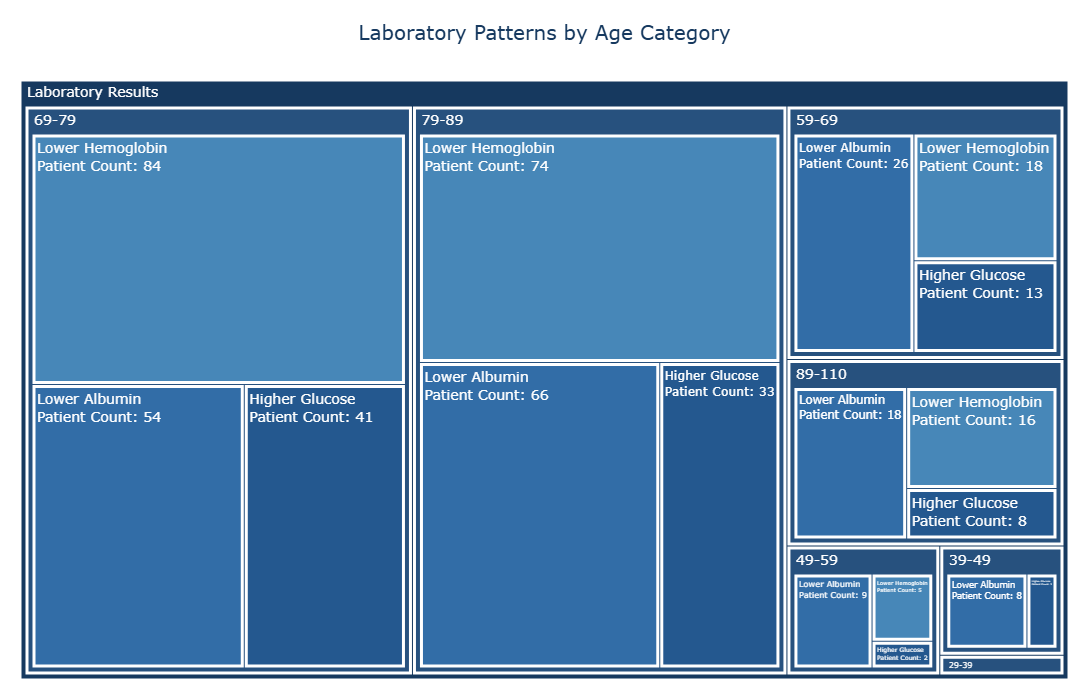

In [27]:
import pandas as pd
import plotly.graph_objects as go

# --------------------------------------------------
# 1. Select laboratory measurements
# --------------------------------------------------

lab_options = {
    "Lower Hemoglobin": (
        ["hemoglobin", "hemoglobin_blood_gas"],
        "low"
    ),

    "Lower Albumin": (
        ["albumin", "albumin_serum"],
        "low"
    ),

    "Higher Glucose": (
        ["glucose_blood_gas", "glucose"],
        "high"
    ),

    "Higher Troponin": (
        ["troponin_i", "troponin_t", "troponin"],
        "high"
    )
}

selected_labs = {}

for label, (options, direction) in lab_options.items():

    col = next(
        (c for c in options if c in patient.columns),
        None
    )

    if col:
        selected_labs[label] = (col, direction)

if not selected_labs:
    raise ValueError("No laboratory measurements found.")


# --------------------------------------------------
# 2. Calculate patient counts
# --------------------------------------------------

results = []

for label, (col, direction) in selected_labs.items():

    tmp = patient[
        ["inpatient_number", "agecat", col]
    ].copy()

    tmp[col] = pd.to_numeric(
        tmp[col],
        errors="coerce"
    )

    tmp = tmp.dropna()

    if tmp.empty:
        continue

    # Count each inpatient number once for each lab test
    tmp = (
        tmp.groupby(
            ["inpatient_number", "agecat"],
            observed=True,
            as_index=False
        )[col]
        .median()
    )

    # Identify lower or higher measurements
    if direction == "low":

        limit = tmp[col].quantile(0.10)

        tmp["selected_result"] = tmp[col] < limit

    else:

        limit = tmp[col].quantile(0.90)

        tmp["selected_result"] = tmp[col] > limit

    # Calculate patient counts by age category
    summary = (
        tmp.groupby(
            "agecat",
            observed=True
        )["selected_result"]
        .agg(
            patients_tested="count",
            patient_count="sum"
        )
        .reset_index()
    )

    summary["Lab Result"] = label

    summary["Patient Percentage"] = (
        summary["patient_count"]
        / summary["patients_tested"]
        * 100
    )

    results.append(summary)


# --------------------------------------------------
# 3. Combine laboratory results
# --------------------------------------------------

if not results:
    raise ValueError("No laboratory results are available.")

lab_summary = pd.concat(
    results,
    ignore_index=True
)

lab_summary = lab_summary.rename(
    columns={
        "agecat": "Age Category"
    }
)

lab_summary["Age Category"] = (
    lab_summary["Age Category"].astype(str)
)

# Keep groups with at least 10 tested patients
plot_data = lab_summary[
    (lab_summary["patients_tested"] >= 10) &
    (lab_summary["patient_count"] > 0)
].copy()

if plot_data.empty:
    raise ValueError("No results available for the Treemap.")


# --------------------------------------------------
# 4. Define blue color palette
# --------------------------------------------------

lab_colors = {
    "Lower Hemoglobin": "#4787B8",
    "Lower Albumin": "#326DA7",
    "Higher Glucose": "#24588F",
    "Higher Troponin": "#123F70"
}


# --------------------------------------------------
# 5. Create Treemap hierarchy
# --------------------------------------------------

nodes = []

# Main category
nodes.append({
    "id": "root",
    "label": "Laboratory Results",
    "parent": "",
    "value": int(plot_data["patient_count"].sum()),
    "color": "#16395F",

    "text": "Laboratory Results",

    "hover": (
        "<b>Laboratory Results</b><br>"
        "Select an age group to view laboratory results."
    )
})


# Age categories
for age, age_data in plot_data.groupby(
    "Age Category",
    sort=False
):

    age_id = f"age_{age}"

    age_count = int(
        age_data["patient_count"].sum()
    )

    nodes.append({
        "id": age_id,
        "label": age,
        "parent": "root",
        "value": age_count,
        "color": "#27517E",

        "text": f"Age: {age}",

        "hover": (
            f"<b>Age Group: {age}</b><br>"
            "Select a laboratory measurement for details."
        )
    })

    # IMPORTANT:
    # Laboratory boxes must be inside the age-group loop.

    for _, row in age_data.iterrows():

        lab_name = row["Lab Result"]

        count = int(row["patient_count"])

        tested = int(row["patients_tested"])

        percentage = float(row["Patient Percentage"])

        nodes.append({
            "id": f"{age_id}_{lab_name}",
            "label": lab_name,
            "parent": age_id,
            "value": count,
            "color": lab_colors[lab_name],

            "text": (
                f"{lab_name}<br>"
                f"Patient Count: {count}"
            ),

            "hover": (
                f"<b>{lab_name}</b><br>"
                f"Age Group: {age}<br>"
                f"Patient Count: {count:,}<br>"
                f"Tested Patients: {tested:,}<br>"
                f"Patient Percentage: {percentage:.1f}%"
            )
        })


# --------------------------------------------------
# 6. Create Treemap
# --------------------------------------------------

fig = go.Figure(

    go.Treemap(
        ids=[
            n["id"]
            for n in nodes
        ],
        labels=[
            n["label"]
            for n in nodes
        ],
        parents=[
            n["parent"]
            for n in nodes
        ],
        values=[
            n["value"]
            for n in nodes
        ],
        branchvalues="total",
        marker=dict(

            colors=[
                n["color"]
                for n in nodes
            ],
            line=dict(
                color="white",
                width=3
            )
        ),
        text=[
            n["text"]
            for n in nodes
        ],

        texttemplate="%{text}",

        hovertext=[
            n["hover"]
            for n in nodes
        ],
        hovertemplate=(
            "%{hovertext}"
            "<extra></extra>"
        ),
        textfont=dict(
            size=14,
            color="white"
        ),
        tiling=dict(
            packing="squarify",
            pad=4
        ),
        pathbar=dict(
            visible=True
        ),
        maxdepth=3
    )
)

# --------------------------------------------------
# 7. Customize chart
# --------------------------------------------------

fig.update_layout(

    title=dict(
        text="Laboratory Patterns by Age Category",
        x=0.5,

        font=dict(
            size=20,
            color="#16395F"
        )
    ),
    height=700,
    paper_bgcolor="white",
    margin=dict(
        t=80,
        l=20,
        r=20,
        b=20
    ),

    font=dict(size=13)
)

fig.show()


### Actual Insight: 
Based on your actual results:*
The older age groups show more patients with lower hemoglobin and albumin levels. Patients aged 69–79 had the highest count of lower hemoglobin measurements, with 84 out of 708 tested patients (11.86%), followed by patients aged 79–89, with 74 out of 639 (11.58%).
The 89–110 age group had a particularly high percentage of lower albumin measurements, with 18 out of 93 tested patients (19.35%).
These findings suggest that older patient groups may benefit from closer review of hemoglobin and albumin measurements.

# PA4: Which age groups show the greatest differences in laboratory values, and which specific lab measurements may require closer clinical attention? 
* Sankey Chart: Laboratory Result Flow Across Age Groups — Prescriptive Analysis *
* Reasoning *

Comparing hemoglobin, albumin, glucose, creatinine, and urea across age groups helps us understand how laboratory results differ among patients. A Sankey chart shows how these measurements are distributed into above, within, and below comparison ranges, helping identify patterns that may need further review.

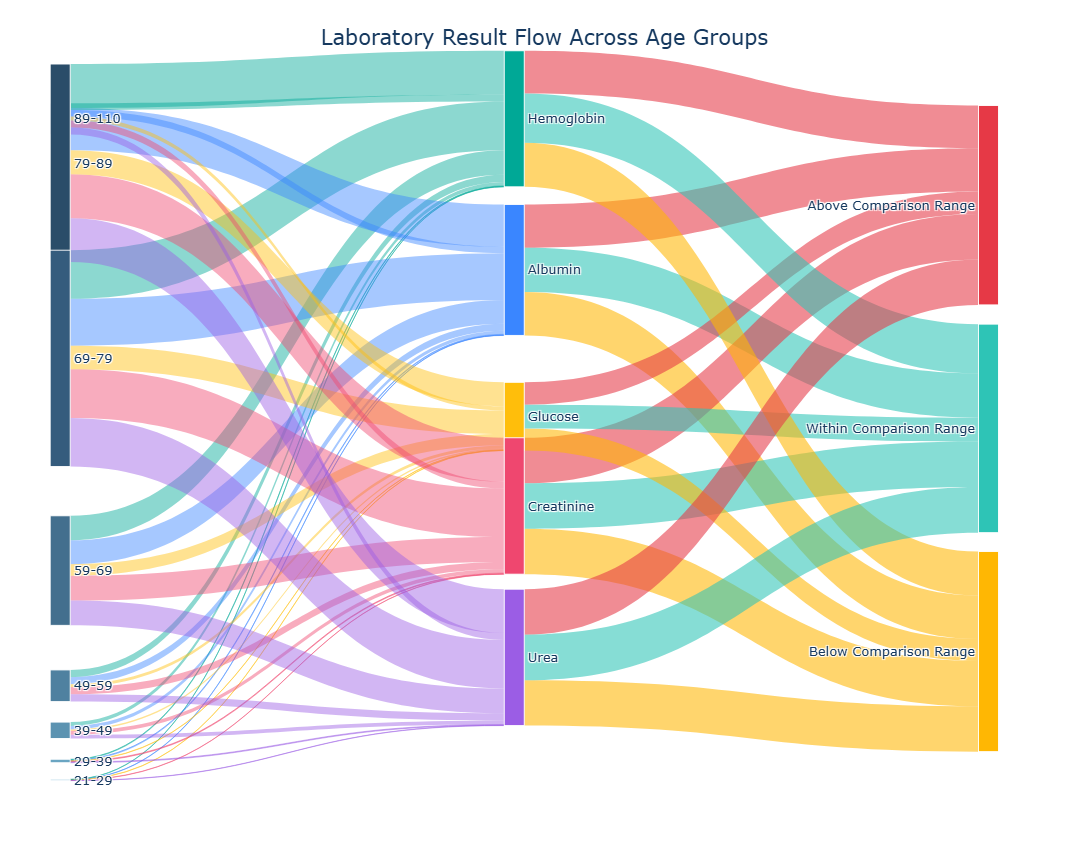

In [8]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import re

# --------------------------------------------------
# 1. Select laboratory biomarkers
# --------------------------------------------------

lab_options = {
    "Hemoglobin": ["hemoglobin", "hemoglobin_blood_gas"],
    "Albumin": ["albumin", "albumin_serum"],
    "Glucose": ["glucose_blood_gas", "glucose"],
    "Creatinine": ["creatinine_enzymatic_method", "creatinine"],
    "Urea": ["urea"]
}

selected_labs = {}

for label, options in lab_options.items():
    col = next((c for c in options if c in patient.columns), None)
    if col:
        selected_labs[label] = col

if not selected_labs:
    raise ValueError("No laboratory biomarkers found.")


# --------------------------------------------------
# 2. Define result categories
# --------------------------------------------------

ABOVE = "Above Comparison Range"
WITHIN = "Within Comparison Range"
BELOW = "Below Comparison Range"

# Keep this exact order for the last column
result_categories = [ABOVE, WITHIN, BELOW]


# --------------------------------------------------
# 3. Prepare laboratory data
# --------------------------------------------------

results = []

for label, col in selected_labs.items():

    tmp = patient[["inpatient_number", "agecat", col]].copy()

    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp[col] = tmp[col].replace([np.inf, -np.inf], np.nan)
    tmp = tmp.dropna()

    if tmp.empty:
        continue

    # Keep one measurement per inpatient number and age group
    tmp = (
        tmp.groupby(
            ["inpatient_number", "agecat"],
            observed=True,
            as_index=False
        )[col]
        .median()
    )

    # Comparison limits based on dataset thirds
    lower = tmp[col].quantile(1/3)
    upper = tmp[col].quantile(2/3)

    if lower >= upper:
        continue

    # Classify results
    tmp["Lab Result"] = np.select(
        [
            tmp[col] > upper,
            tmp[col] < lower
        ],
        [
            ABOVE,
            BELOW
        ],
        default=WITHIN
    )

    tested = (
        tmp.groupby("agecat", observed=True)
        .size()
        .rename("Tested Patients")
        .reset_index()
    )

    summary = (
        tmp.groupby(
            ["agecat", "Lab Result"],
            observed=True
        )
        .size()
        .reset_index(name="Patient Count")
    )

    summary = summary.merge(
        tested,
        on="agecat",
        how="left"
    )

    summary["Biomarker"] = label
    summary["Patient Percentage"] = (
        summary["Patient Count"] / summary["Tested Patients"] * 100
    )

    results.append(summary)

if not results:
    raise ValueError("No laboratory results available.")

sankey_df = pd.concat(results, ignore_index=True)
sankey_df = sankey_df.rename(columns={"agecat": "Age Category"})
sankey_df["Age Category"] = sankey_df["Age Category"].astype(str)


# --------------------------------------------------
# 4. Define improved colors
# --------------------------------------------------

# Richer biomarker colors
lab_colors = {
    "Hemoglobin": "#00A896",   # bright teal
    "Albumin": "#3A86FF",      # vivid blue
    "Glucose": "#FFBE0B",      # bright yellow
    "Creatinine": "#EF476F",   # vivid pink-red
    "Urea": "#9B5DE5"          # vibrant purple
}

# Age-group colors: darker blue-teal family
age_colors = [
    "#1D3557",
    "#2A4D69",
    "#355C7D",
    "#436F8E",
    "#4F81A0",
    "#5C93B1",
    "#6AA5C2",
    "#78B7D3"
]

# Result-category colors
result_colors = {
    ABOVE: "#E63946",   # vivid red
    WITHIN: "#2EC4B6",  # brighter teal
    BELOW: "#FFB703"    # brighter yellow
}


# --------------------------------------------------
# 5. Create correctly ordered node lists
# --------------------------------------------------

def age_sort_key(age):
    nums = re.findall(r"\d+", str(age))
    return int(nums[0]) if nums else -1

# DESCENDING age order
age_nodes = sorted(
    sankey_df["Age Category"].unique(),
    key=age_sort_key,
    reverse=True
)

lab_nodes = [lab for lab in lab_options if lab in sankey_df["Biomarker"].unique()]
result_nodes = [r for r in result_categories if r in sankey_df["Lab Result"].unique()]

age_ids = [f"age:{x}" for x in age_nodes]
lab_ids = [f"lab:{x}" for x in lab_nodes]
result_ids = [f"result:{x}" for x in result_nodes]

all_ids = age_ids + lab_ids + result_ids
all_labels = age_nodes + lab_nodes + result_nodes

node_map = {node_id: i for i, node_id in enumerate(all_ids)}


# --------------------------------------------------
# 6. Create Sankey connections
# --------------------------------------------------

links_1 = (
    sankey_df.groupby(
        ["Age Category", "Biomarker"],
        observed=True
    )["Patient Count"]
    .sum()
    .reset_index()
)

links_2 = (
    sankey_df.groupby(
        ["Biomarker", "Lab Result"],
        observed=True
    )["Patient Count"]
    .sum()
    .reset_index()
)

source = (
    [node_map[f"age:{age}"] for age in links_1["Age Category"]] +
    [node_map[f"lab:{lab}"] for lab in links_2["Biomarker"]]
)

target = (
    [node_map[f"lab:{lab}"] for lab in links_1["Biomarker"]] +
    [node_map[f"result:{result}"] for result in links_2["Lab Result"]]
)

values = (
    links_1["Patient Count"].tolist() +
    links_2["Patient Count"].tolist()
)


# --------------------------------------------------
# 7. Assign node colors
# --------------------------------------------------

node_colors = []

for label in all_labels:
    if label in age_nodes:
        node_colors.append(age_colors[age_nodes.index(label) % len(age_colors)])
    elif label in lab_nodes:
        node_colors.append(lab_colors[label])
    else:
        node_colors.append(result_colors[label])


# --------------------------------------------------
# 8. Create transparent link colors
# --------------------------------------------------

def hex_to_rgba(hex_color, opacity=0.55):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{opacity})"

link_colors = []

# Age -> Biomarker links use biomarker colors
for lab in links_1["Biomarker"]:
    link_colors.append(hex_to_rgba(lab_colors[lab], opacity=0.45))

# Biomarker -> Result links use result colors
for result in links_2["Lab Result"]:
    link_colors.append(hex_to_rgba(result_colors[result], opacity=0.58))


# --------------------------------------------------
# 9. Position nodes
# --------------------------------------------------

CHART_HEIGHT = 850
PLOT_HEIGHT = 730
NODE_PAD = 16

total_flow = links_1["Patient Count"].sum()
max_nodes = max(len(age_nodes), len(lab_nodes), len(result_nodes))
usable_height = PLOT_HEIGHT * 0.92

flow_scale = (
    usable_height - (max_nodes - 1) * NODE_PAD
) / total_flow


def calculate_positions(labels, counts):
    counts = np.array(counts, dtype=float)
    total_node_height = counts.sum() * flow_scale

    if len(labels) > 1:
        gap = (usable_height - total_node_height) / (len(labels) - 1)
    else:
        gap = 0

    positions = []
    current_y = PLOT_HEIGHT * 0.04

    for count in counts:
        positions.append(current_y / PLOT_HEIGHT)
        current_y += count * flow_scale + gap

    return positions


# Age-group positions (descending order already set)
age_counts = (
    links_1.groupby("Age Category")["Patient Count"]
    .sum()
    .reindex(age_nodes)
    .fillna(0)
)
age_y = calculate_positions(age_nodes, age_counts.values)

# Biomarker positions
lab_counts = (
    links_1.groupby("Biomarker")["Patient Count"]
    .sum()
    .reindex(lab_nodes)
    .fillna(0)
)
lab_y = calculate_positions(lab_nodes, lab_counts.values)

# Result positions: top -> above, middle -> within, bottom -> below
result_y_map = {
    ABOVE: 0.16,
    WITHIN: 0.47,
    BELOW: 0.78
}
result_y = [result_y_map[r] for r in result_nodes]

x_positions = (
    [0.02] * len(age_nodes) +
    [0.47] * len(lab_nodes) +
    [0.94] * len(result_nodes)
)

y_positions = age_y + lab_y + result_y


# --------------------------------------------------
# 10. Create Sankey chart
# --------------------------------------------------

fig = go.Figure(
    go.Sankey(
        arrangement="fixed",

        node=dict(
            pad=NODE_PAD,
            thickness=20,
            line=dict(color="white", width=0.9),
            label=all_labels,
            color=node_colors,
            x=x_positions,
            y=y_positions,
            hovertemplate=(
                "<b>%{label}</b><br>"
                "Count: %{value:,.0f}"
                "<extra></extra>"
            )
        ),

        link=dict(
            source=source,
            target=target,
            value=values,
            color=link_colors,
            hovertemplate=(
                "<b>%{source.label}</b> → <b>%{target.label}</b><br>"
                "Count: %{value:,.0f}"
                "<extra></extra>"
            )
        )
    )
)


# --------------------------------------------------
# 11. Customize chart appearance
# --------------------------------------------------

fig.update_layout(
    title=dict(
        text="Laboratory Result Flow Across Age Groups",
        x=0.5,
        font=dict(
            size=21,
            color="#16395F"
        )
    ),
    height=CHART_HEIGHT,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(
        size=13,
        color="#16395F"
    ),
    margin=dict(
        t=90,
        l=40,
        r=40,
        b=40
    )
)

fig.show()


* Actual Insight

The chart shows that older age groups, particularly 69–79 and 79–89, account for a larger number of laboratory results across the different comparison ranges. Hemoglobin, albumin, glucose, creatinine, and urea show different distributions across these groups. This helps identify which laboratory measurements may need closer attention when reviewing older patients.

# PA5: Among patients receiving multiple medications, which age groups show the greatest medication burden, and how do their glucose levels differ across these groups? 

## Prescription Medication and Laboratory Results — Sunburst Chart
### Reasoning

Combining prescription records with glucose measurements helps us understand how laboratory results vary among patients taking different numbers of medications. A Sunburst chart shows these patterns across age groups, making it easier to identify patient groups that may benefit from further laboratory and medication review.

Medication column: drug_name


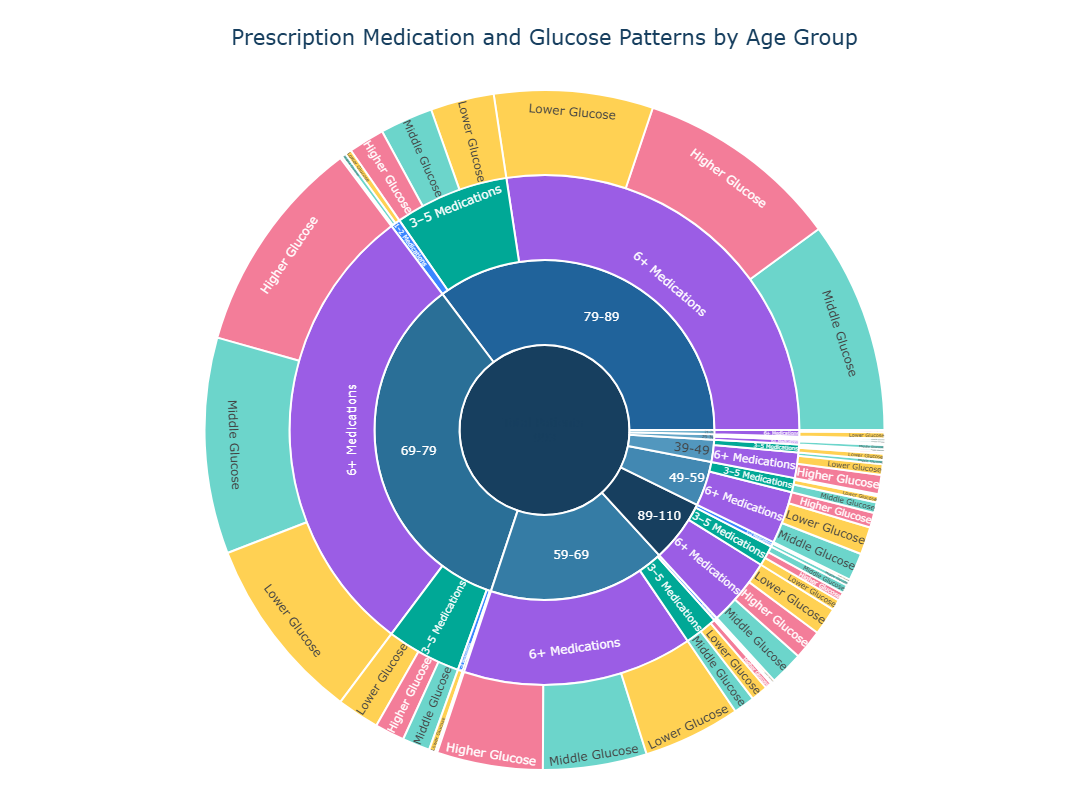

In [9]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import re

# --------------------------------------------------
# 1. Define columns
# --------------------------------------------------

ID_COL = "inpatient_number"
AGE_COL = "agecat"
GLUCOSE_COL = "glucose_blood_gas"

# Identify medication column
med_options = [
    "drug_name",
    "medication_name",
    "medicine_name",
    "prescription_name",
    "generic_name",
    "drug",
    "medication",
    "medicine",
    "drug_class",
    "drug_code"
]

MED_COL = next(
    (col for col in med_options if col in prescriptions.columns),
    None
)

if MED_COL is None:

    print("Available prescription columns:")
    print(prescriptions.columns.tolist())

    raise ValueError(
        "Please select the correct medication column."
    )

print("Medication column:", MED_COL)


# --------------------------------------------------
# 2. Prepare patient and glucose data
# --------------------------------------------------

tmp = patient[
    [ID_COL, AGE_COL, GLUCOSE_COL]
].copy()

tmp[GLUCOSE_COL] = pd.to_numeric(
    tmp[GLUCOSE_COL],
    errors="coerce"
)

tmp[GLUCOSE_COL] = tmp[GLUCOSE_COL].replace(
    [np.inf, -np.inf],
    np.nan
)

tmp = tmp.dropna(
    subset=[ID_COL, AGE_COL, GLUCOSE_COL]
)

# Standardize inpatient IDs
tmp[ID_COL] = (
    tmp[ID_COL]
    .astype(str)
    .str.strip()
)

# Keep one glucose measurement per inpatient ID
# Use the median if multiple results are available
glucose_data = (
    tmp.groupby(
        ID_COL,
        as_index=False
    )
    .agg({
        AGE_COL: "first",
        GLUCOSE_COL: "median"
    })
)


# --------------------------------------------------
# 3. Count distinct prescribed medications
# --------------------------------------------------

med_data = prescriptions[
    [ID_COL, MED_COL]
].copy()

med_data = med_data.dropna()

med_data[ID_COL] = (
    med_data[ID_COL]
    .astype(str)
    .str.strip()
)

med_data[MED_COL] = (
    med_data[MED_COL]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove blank medication names
med_data = med_data[
    med_data[MED_COL] != ""
]

# Count unique medication names per inpatient ID
med_counts = (
    med_data.groupby(ID_COL)[MED_COL]
    .nunique()
    .reset_index(name="Medication Count")
)

# Combine glucose and prescription information
sunburst_data = glucose_data.merge(
    med_counts,
    on=ID_COL,
    how="left"
)

# No matching prescription record
sunburst_data["Medication Count"] = (
    sunburst_data["Medication Count"]
    .fillna(0)
    .astype(int)
)


# --------------------------------------------------
# 4. Create medication categories
# --------------------------------------------------

def medication_group(count):

    if count == 0:
        return "No Prescription Listed"

    elif count <= 2:
        return "1–2 Medications"

    elif count <= 5:
        return "3–5 Medications"

    else:
        return "6+ Medications"


sunburst_data["Medication Group"] = (
    sunburst_data["Medication Count"]
    .apply(medication_group)
)


# --------------------------------------------------
# 5. Create glucose comparison categories
# --------------------------------------------------

lower = sunburst_data[GLUCOSE_COL].quantile(1/3)
upper = sunburst_data[GLUCOSE_COL].quantile(2/3)

if lower >= upper:
    raise ValueError(
        "Glucose values cannot be divided into three distinct groups."
    )

sunburst_data["Glucose Level"] = np.select(

    [
        sunburst_data[GLUCOSE_COL] < lower,
        sunburst_data[GLUCOSE_COL] > upper
    ],

    [
        "Lower Glucose",
        "Higher Glucose"
    ],

    default="Middle Glucose"
)


# --------------------------------------------------
# 6. Prepare summary for Sunburst
# --------------------------------------------------

sunburst_data["Age Category"] = (
    sunburst_data[AGE_COL].astype(str)
)

summary = (
    sunburst_data.groupby(
        [
            "Age Category",
            "Medication Group",
            "Glucose Level"
        ],
        observed=True
    )
    .size()
    .reset_index(name="Patient Count")
)

# Total tested patients in each age and medication group
summary["Tested Patients"] = (
    summary.groupby(
        ["Age Category", "Medication Group"]
    )["Patient Count"]
    .transform("sum")
)

summary["Patient Percentage"] = (
    summary["Patient Count"]
    / summary["Tested Patients"]
    * 100
)


# --------------------------------------------------
# 7. Define colors
# --------------------------------------------------

age_colors = [
    "#173F5F",
    "#20639B",
    "#2A6F97",
    "#357CA5",
    "#4288B2",
    "#5297BE",
    "#63A5C6",
    "#74B3CE"
]

med_colors = {
    "No Prescription Listed": "#94A3B8",
    "1–2 Medications": "#3A86FF",
    "3–5 Medications": "#00A896",
    "6+ Medications": "#9B5DE5"
}

glucose_colors = {
    "Lower Glucose": "#FFBE0B",
    "Middle Glucose": "#2EC4B6",
    "Higher Glucose": "#EF476F"
}


# --------------------------------------------------
# 8. Define category order
# --------------------------------------------------

def age_sort_key(age):

    numbers = re.findall(
        r"\d+",
        str(age)
    )

    return int(numbers[0]) if numbers else -1


age_nodes = sorted(
    summary["Age Category"].unique(),
    key=age_sort_key,
    reverse=True
)

med_nodes = [
    "No Prescription Listed",
    "1–2 Medications",
    "3–5 Medications",
    "6+ Medications"
]

glucose_nodes = [
    "Higher Glucose",
    "Middle Glucose",
    "Lower Glucose"
]


# --------------------------------------------------
# 9. Build Sunburst hierarchy
# --------------------------------------------------

nodes = []

def add_node(node_id, label, parent, count, color, hover):

    nodes.append({
        "id": node_id,
        "label": label,
        "parent": parent,
        "value": int(count),
        "color": color,
        "hover": hover
    })


# Main circle - Total Patients

total_patients = int(
    summary["Patient Count"].sum()
)

add_node(
    "root",
    f"Total Patients<br>{total_patients:,}",
    "",
    total_patients,
    "#173F5F",
    (
        f"<b>Total Patients: {total_patients:,}</b><br>"
    )
)


# Age groups
for i, age in enumerate(age_nodes):

    age_data = summary[
        summary["Age Category"] == age
    ]

    age_id = f"age:{age}"

    age_count = age_data["Patient Count"].sum()

    add_node(
        age_id,
        age,
        "root",
        age_count,
        age_colors[i % len(age_colors)],
        (
            f"<b>Age Group: {age}</b><br>"
            f"Tested Patients: {int(age_count):,}"
        )
    )

    # Medication groups
    for med in med_nodes:

        med_data_group = age_data[
            age_data["Medication Group"] == med
        ]

        if med_data_group.empty:
            continue

        med_id = f"{age_id}|med:{med}"

        med_count = med_data_group[
            "Patient Count"
        ].sum()

        add_node(
            med_id,
            med,
            age_id,
            med_count,
            med_colors[med],
            (
                f"<b>{med}</b><br>"
                f"Age Group: {age}<br>"
                f"Patient Count: {int(med_count):,}"
            )
        )

        # Glucose categories
        for glucose in glucose_nodes:

            glucose_data_group = med_data_group[
                med_data_group["Glucose Level"] == glucose
            ]

            if glucose_data_group.empty:
                continue

            row = glucose_data_group.iloc[0]

            count = int(row["Patient Count"])
            tested = int(row["Tested Patients"])
            percentage = float(row["Patient Percentage"])

            add_node(
                f"{med_id}|glucose:{glucose}",
                glucose,
                med_id,
                count,
                glucose_colors[glucose],

                (
                    f"<b>{glucose}</b><br>"
                    f"Age Group: {age}<br>"
                    f"Medication Group: {med}<br>"
                    f"Patient Count: {count:,}<br>"
                    f"Tested Patients: {tested:,}<br>"
                    f"Patient Percentage: {percentage:.1f}%"
                )
            )


# --------------------------------------------------
# 10. Create Sunburst chart
# --------------------------------------------------

fig = go.Figure(

    go.Sunburst(

        ids=[
            n["id"]
            for n in nodes
        ],

        labels=[
            n["label"]
            for n in nodes
        ],

        parents=[
            n["parent"]
            for n in nodes
        ],

        values=[
            n["value"]
            for n in nodes
        ],

        branchvalues="total",

        marker=dict(
            colors=[
                n["color"]
                for n in nodes
            ],

            line=dict(
                color="white",
                width=2
            )
        ),

        customdata=[
            n["hover"]
            for n in nodes
        ],

        hovertemplate=(
            "%{customdata}"
            "<extra></extra>"
        ),

        text=[
            f"Total Patients <br>{total_patients:,}"
                if n["id"] == "root"
                else n["label"]
                for n in nodes
            ],

        textinfo="text",
        texttemplate="%{text}",
        insidetextorientation="auto",
        maxdepth=4

    )
)


# --------------------------------------------------
# 11. Customize chart appearance
# --------------------------------------------------

fig.update_layout(

    title=dict(
        text="Prescription Medication and Glucose Patterns by Age Group",
        x=0.5,
        font=dict(
            size=21,
            color="#173F5F"
        )
    ),

    height=800,

    paper_bgcolor="white",

    font=dict(
        size=12,
        color="#173F5F"
    ),

    margin=dict(
        t=90,
        l=30,
        r=30,
        b=30
    )
)

fig.show()



## Actual Insight:
The code will automatically identify the age and medication group with the highest percentage of higher glucose measurements, among groups with at least 30 tested inpatient records.

You can use that output as the starting point for your notebook's Actual Insight. We should describe the specific age group, medication count, and percentage after you execute it.

## PA7.Which age groups show clinically meaningful differences in laboratory values and blood pressure measurements that may indicate a need for closer monitoring or follow-up?
## Laboratory and Blood Pressure Profiles by Age Category
## Reasoning
Comparing hemoglobin, glucose, creatinine, and systolic blood pressure across age groups helps us understand how these health measurements are related. A Pair Plot shows how the measurements vary together and helps identify age groups with patterns that may need further review.

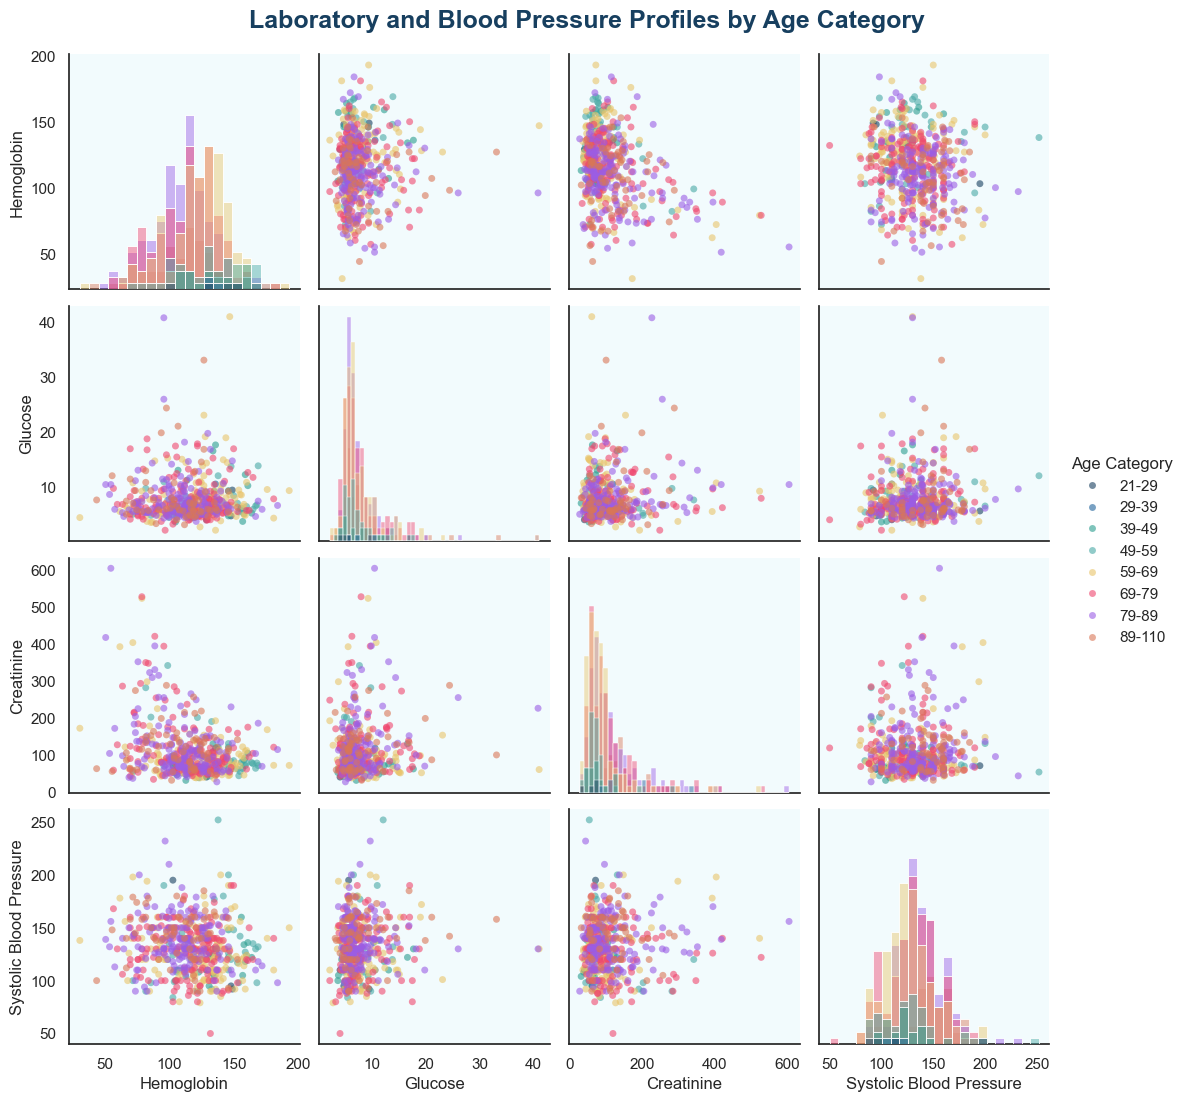

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --------------------------------------------------
# 1. Select laboratory and blood pressure measurements
# --------------------------------------------------

selected_columns = {
    "hemoglobin": "Hemoglobin",
    "glucose_blood_gas": "Glucose",
    "creatinine_enzymatic_method": "Creatinine",
    "systolic_blood_pressure": "Systolic Blood Pressure"
}

# Check available columns
available_columns = {
    col: label
    for col, label in selected_columns.items()
    if col in patient.columns
}

if len(available_columns) < 3:
    raise ValueError(
        "At least three measurements are required."
    )


# --------------------------------------------------
# 2. Prepare patient data
# --------------------------------------------------

tmp = patient[
    ["inpatient_number", "agecat"]
    + list(available_columns.keys())
].copy()

# Convert measurements to numeric
for col in available_columns:

    tmp[col] = pd.to_numeric(
        tmp[col],
        errors="coerce"
    )

    tmp[col] = tmp[col].replace(
        [np.inf, -np.inf],
        np.nan
    )

# Remove records without age or inpatient number
tmp = tmp.dropna(
    subset=["inpatient_number", "agecat"]
)

# Keep one laboratory profile per inpatient number
tmp = (
    tmp.groupby(
        "inpatient_number",
        as_index=False
    )
    .agg({
        "agecat": "first",
        **{
            col: "median"
            for col in available_columns
        }
    })
)

# Rename columns
tmp = tmp.rename(
    columns=available_columns
)

tmp = tmp.rename(
    columns={"agecat": "Age Category"}
)

markers = list(available_columns.values())

# Keep complete profiles
tmp = tmp.dropna(
    subset=markers
)

if tmp.empty:
    raise ValueError(
        "No complete laboratory profiles available."
    )


# --------------------------------------------------
# 3. Arrange age categories
# --------------------------------------------------

def age_sort_key(age):

    numbers = re.findall(
        r"\d+",
        str(age)
    )

    return int(numbers[0]) if numbers else -1


tmp["Age Category"] = (
    tmp["Age Category"].astype(str)
)

age_order = sorted(
    tmp["Age Category"].unique(),
    key=age_sort_key
)


# --------------------------------------------------
# 4. Define colors
# --------------------------------------------------

colors = [
    "#173F5F",
    "#20639B",
    "#2A9D8F",
    "#48A9A6",
    "#E9C46A",
    "#EF476F",
    "#9B5DE5",
    "#D97757"
]

palette = {
    age: colors[i % len(colors)]
    for i, age in enumerate(age_order)
}


# --------------------------------------------------
# 5. Prepare data for visualization
# --------------------------------------------------

# Use a maximum of 150 records per age category
# to prevent too many overlapping points.

MAX_PER_AGE = 150

plot_data = pd.concat(
    [
        group.sample(
            n=min(len(group), MAX_PER_AGE),
            random_state=42
        )

        for _, group in tmp.groupby(
            "Age Category"
        )
    ],
    ignore_index=True
)


# --------------------------------------------------
# 6. Create Pair Plot
# --------------------------------------------------

sns.set_theme(
    style="white",
    font_scale=1.0
)

g = sns.pairplot(

    data=plot_data,

    vars=markers,

    hue="Age Category",

    hue_order=age_order,

    palette=palette,

    diag_kind="hist",

    diag_kws={
        "alpha": 0.45
    },

    plot_kws={
        "alpha": 0.60,
        "s": 25,
        "edgecolor": "none"
    },

    height=2.7,

    aspect=1
)


# --------------------------------------------------
# 7. Customize chart
# --------------------------------------------------

g.fig.suptitle(
    "Laboratory and Blood Pressure Profiles by Age Category",
    fontsize=18,
    fontweight="bold",
    color="#173F5F",
    y=1.02
)

g.fig.set_facecolor("white")

for ax in g.axes.flat:

    if ax is not None:

        ax.set_facecolor("#F2FBFD")

        ax.grid(
            False
        )

if g._legend is not None:

    g._legend.set_title(
        "Age Category"
    )

plt.show()




## Actual Insight

The Pair Plot helps identify differences in laboratory measurements and blood pressure across age groups. It also shows whether certain measurements tend to increase or decrease together. These patterns can help highlight patient groups that may benefit from closer laboratory and blood pressure monitoring.

## PA8: How do key clinical biomarkers—hemoglobin, albumin, glucose, and creatinine—vary across age groups, and what age-related patterns emerge in these laboratory measurements? 
## Reasoning

Comparing laboratory measurements across age groups helps us understand how values differ among patients. A violin chart shows where most measurements are concentrated, how much they vary, and whether certain age groups have unusually high or low values.

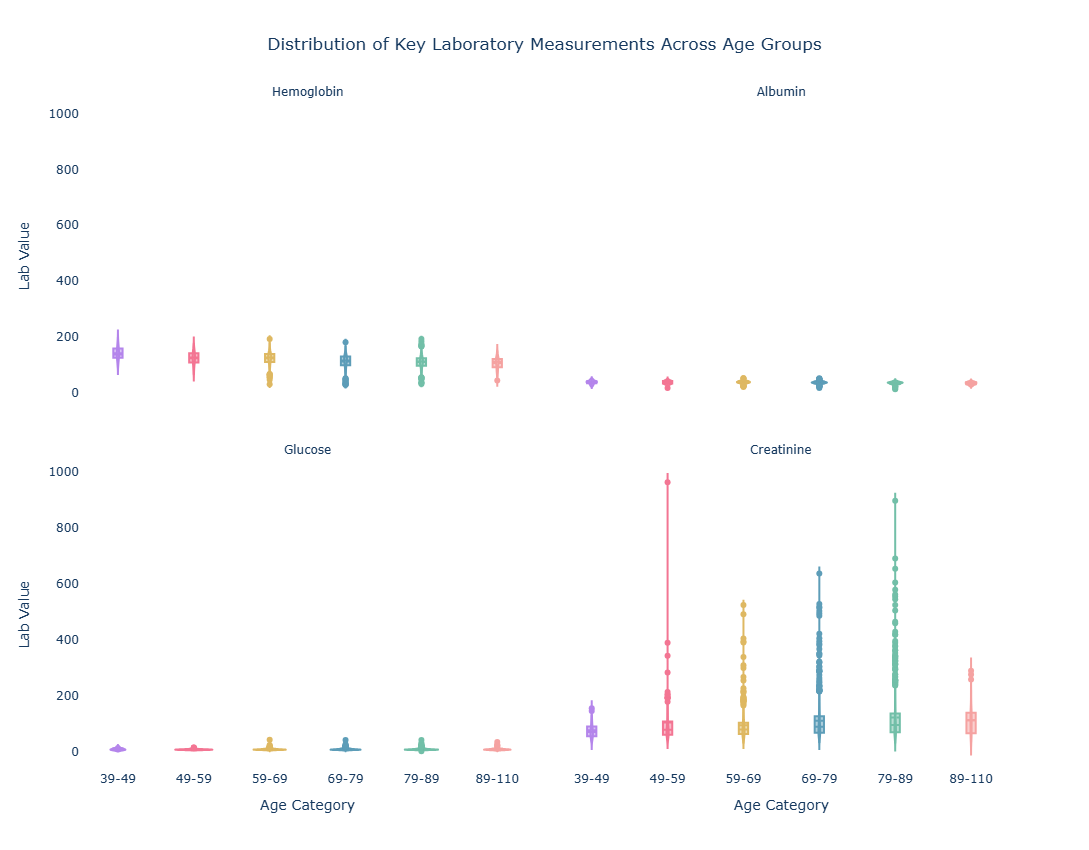


Actual Insight:

Creatinine showed the widest spread in the 89-110 age group. The median value was 110.90, and the middle 50% of values ranged from 64.40 to 138.10. This suggests that patients in this age group had more variation in creatinine than the other groups shown.


In [12]:
import pandas as pd
import numpy as np
import plotly.express as px
import re

# --------------------------------------------------
# 1. Select laboratory biomarkers
# --------------------------------------------------

lab_options = {
    "Hemoglobin": ["hemoglobin", "hemoglobin_blood_gas"],
    "Albumin": ["albumin", "albumin_serum"],
    "Glucose": ["glucose_blood_gas", "glucose"],
    "Creatinine": ["creatinine_enzymatic_method", "creatinine"]
}

selected_labs = {}

for label, options in lab_options.items():
    col = next((c for c in options if c in patient.columns), None)
    if col:
        selected_labs[label] = col

if len(selected_labs) < 2:
    raise ValueError("At least two laboratory biomarkers are required.")


# --------------------------------------------------
# 2. Prepare patient data
# --------------------------------------------------

tmp = patient[
    ["inpatient_number", "agecat"] + list(selected_labs.values())
].copy()

# Convert lab values to numeric
for col in selected_labs.values():
    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp[col] = tmp[col].replace([np.inf, -np.inf], np.nan)

# Remove rows missing inpatient ID or age category
tmp = tmp.dropna(subset=["inpatient_number", "agecat"])

# Keep one lab profile per inpatient number
tmp = (
    tmp.groupby("inpatient_number", as_index=False)
    .agg({
        "agecat": "first",
        **{col: "median" for col in selected_labs.values()}
    })
)

# Rename columns for readability
tmp = tmp.rename(
    columns={
        "agecat": "Age Category",
        **{col: label for label, col in selected_labs.items()}
    }
)

# --------------------------------------------------
# 3. Arrange age groups
# --------------------------------------------------

def age_sort_key(age):
    numbers = re.findall(r"\d+", str(age))
    return int(numbers[0]) if numbers else -1

tmp["Age Category"] = tmp["Age Category"].astype(str)

age_order = sorted(
    tmp["Age Category"].dropna().unique(),
    key=age_sort_key
)

# --------------------------------------------------
# 4. Convert to long format
# --------------------------------------------------

long_df = tmp.melt(
    id_vars=["inpatient_number", "Age Category"],
    value_vars=list(selected_labs.keys()),
    var_name="Biomarker",
    value_name="Lab Value"
)

long_df = long_df.dropna(subset=["Lab Value"])

# Keep only age groups with enough records
age_counts = (
    long_df.groupby(["Biomarker", "Age Category"], observed=True)
    .size()
    .reset_index(name="Patient Count")
)

valid_groups = age_counts[age_counts["Patient Count"] >= 20][
    ["Biomarker", "Age Category"]
]

long_df = long_df.merge(
    valid_groups,
    on=["Biomarker", "Age Category"],
    how="inner"
)

if long_df.empty:
    raise ValueError("Not enough data available for the violin chart.")


# --------------------------------------------------
# 5. Create violin chart
# --------------------------------------------------

color_map = {
    "21-29": "#3A86FF",
    "29-39": "#00A896",
    "39-49": "#9B5DE5",
    "49-59": "#EF476F",
    "59-69": "#D4A12E",
    "69-79": "#277DA1",
    "79-89": "#43AA8B",
    "89-110": "#F28482"
}

fig = px.violin(
    long_df,
    x="Age Category",
    y="Lab Value",
    color="Age Category",
    facet_col="Biomarker",
    facet_col_wrap=2,
    box=True,
    points="outliers",
    category_orders={"Age Category": age_order},
    color_discrete_map=color_map,
    title="Distribution of Key Laboratory Measurements Across Age Groups"
)

fig.update_traces(
    meanline_visible=True,
    opacity=0.75
)

fig.update_layout(
    height=850,
    title_x=0.5,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(size=12, color="#16395F"),
    showlegend=False
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.for_each_annotation(
    lambda a: a.update(text=a.text.split("=")[-1])
)

fig.show()


# --------------------------------------------------
# 6. Generate actual insight
# --------------------------------------------------

summary = (
    long_df.groupby(["Biomarker", "Age Category"], observed=True)["Lab Value"]
    .agg(
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Count="count"
    )
    .reset_index()
)

summary["IQR"] = summary["Q3"] - summary["Q1"]

# Keep groups with enough records
summary = summary[summary["Count"] >= 20]

if not summary.empty:
    top = summary.sort_values("IQR", ascending=False).iloc[0]

    print("\nActual Insight:\n")
    print(
        f"{top['Biomarker']} showed the widest spread in the "
        f"{top['Age Category']} age group. "
        f"The median value was {top['Median']:.2f}, and the middle 50% "
        f"of values ranged from {top['Q1']:.2f} to {top['Q3']:.2f}. "
        f"This suggests that patients in this age group had more variation "
        f"in {top['Biomarker'].lower()} than the other groups shown."
    )
else:
    print("Not enough age groups had enough records to generate an insight.")

## Actual Insight

The violin chart highlights differences in laboratory measurements across age groups. Some groups may show a wider spread of values, while others have measurements concentrated within a smaller range. These patterns help us understand how laboratory profiles vary with age and identify measurements that may need further investigation.

### PA10: Which patient groups at hospital discharge, based on their demographic, cardiac, comorbidity, laboratory, neurological, respiratory, hospital stay, and medication characteristics, have higher rates of readmission or emergency department return, and which groups may need enhanced discharge planning and earlier follow-up?

### Type of Analysis
Prescriptive Analysis: Clustered Heatmap with Dendrogram and Post-Discharge Outcome Bar Chart
### Reasoning
This prescriptive analysis groups patients with similar discharge characteristics and compares their readmission and ED-return patterns to identify groups that may benefit from closer follow-up and enhanced discharge planning.

In [13]:

# ============================================================
# 1. IMPORTS AND FILE SETUP
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# File resolver:
# The notebook works if the CSV files are either:
#   1) in the same folder as this notebook, OR
#   2) in /mnt/data (ChatGPT environment).
# ------------------------------------------------------------

# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\__Final_Cleaned Dataset"
)

# Define CSV filenames


FILES = {
    "cardiac": "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv",
    "demography": "Team7_CodeAvengers_Category1_DataCleaning_demography.csv",
    "hospital": "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv", 
    "labs": "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    "prescriptions": "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    "history": "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv",
    "responsiveness": "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv"
    }


In [14]:

# ============================================================
# 2. LOAD ALL CLEANED DATASETS
# ============================================================


# Read the cleaned datasets
cardiac = pd.read_csv(project_folder / FILES["cardiac"])
demography = pd.read_csv(project_folder / FILES["demography"])
hospital = pd.read_csv(project_folder / FILES["hospital"])
labs = pd.read_csv(project_folder / FILES["labs"])
prescriptions = pd.read_csv(project_folder / FILES["prescriptions"])
history = pd.read_csv(project_folder / FILES["history"])
responsiveness = pd.read_csv(project_folder / FILES["responsiveness"])

datasets = {
    "Cardiac": cardiac,
    "Demography": demography,
    "Hospitalization/Discharge": hospital,
    "Labs": labs,
    "Prescriptions": prescriptions,
    "Patient History": history,
    "Responsiveness": responsiveness
}

print("Dataset dimensions")
for name, df in datasets.items():
    print(f"{name:25s}: {df.shape[0]:5d} rows x {df.shape[1]:3d} columns")

# Confirm merge key
for name, df in datasets.items():
    if "inpatient_number" not in df.columns:
        raise KeyError(f"'inpatient_number' is missing from {name}.")


Dataset dimensions
Cardiac                  :  2008 rows x  14 columns
Demography               :  2008 rows x   7 columns
Hospitalization/Discharge:  2008 rows x  21 columns
Labs                     :  2008 rows x 107 columns
Prescriptions            : 15362 rows x   2 columns
Patient History          :  2008 rows x  17 columns
Responsiveness           :  2008 rows x   6 columns


In [15]:

# ============================================================
# 3. AGGREGATE PRESCRIPTIONS TO ONE ROW PER PATIENT
# ============================================================

# Prescription data contains multiple rows per patient.
# Convert it into patient-level medication burden before merging.
rx_agg = (
    prescriptions
    .groupby("inpatient_number", as_index=False)
    .agg(
        medication_count=("drug_name", "size"),
        unique_medications=("drug_name", "nunique")
    )
)

print("Prescription records:", len(prescriptions))
print("Patients with prescription records:", rx_agg["inpatient_number"].nunique())


Prescription records: 15362
Patients with prescription records: 2007


In [16]:

# ============================================================
# 4. MERGE ALL SEVEN DATA SOURCES
# ============================================================

merged = (
    demography
    .merge(cardiac, on="inpatient_number", how="inner")
    .merge(history, on="inpatient_number", how="inner")
    .merge(labs, on="inpatient_number", how="inner")
    .merge(responsiveness, on="inpatient_number", how="inner")
    .merge(hospital, on="inpatient_number", how="inner")
    .merge(rx_agg, on="inpatient_number", how="left")
)

merged[["medication_count", "unique_medications"]] = (
    merged[["medication_count", "unique_medications"]].fillna(0)
)

print("Merged patient-level dataset:", merged.shape)
print("Unique patients:", merged["inpatient_number"].nunique())


Merged patient-level dataset: (2008, 169)
Unique patients: 2008


In [17]:

# ============================================================
# 5. DERIVE ANALYSIS VARIABLES
# ============================================================

# Approximate numeric age from the provided age categories.
# This preserves the dataset's existing categorization while allowing clustering.
age_midpoint_map = {
    "21-29": 25.0,
    "29-39": 34.0,
    "39-49": 44.0,
    "49-59": 54.0,
    "59-69": 64.0,
    "69-79": 74.0,
    "79-89": 84.0,
    "89-110": 99.5
}
merged["age_midpoint"] = merged["agecat"].map(age_midpoint_map)

# Respiratory-support indicators
merged["imv_flag"] = (
    merged["respiratory_support"].astype(str).str.upper().eq("IMV")
).astype(int)

merged["oxygen_therapy_flag"] = (
    merged["oxygen_inhalation"].astype(str).str.lower().str.contains("oxygen")
).astype(int)

# Comorbidity count across available binary history indicators
comorbidity_columns = [
    "cerebrovascular_disease",
    "dementia",
    "chronic_obstructive_pulmonary_disease",
    "connective_tissue_disease",
    "peptic_ulcer_disease",
    "diabetes",
    "moderate_to_severe_chronic_kidney_disease",
    "hemiplegia",
    "malignant_lymphoma",
    "solid_tumor",
    "liver_disease",
    "aids",
    "acute_renal_failure"
]

merged["comorbidity_count"] = (
    merged[comorbidity_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

# Primary prescriptive outcome:
# 1 if the patient had either 6-month readmission OR 6-month ED return.
merged["post_discharge_utilization_6m"] = (
    merged[
        [
            "re_admission_within_6_months",
            "return_to_emergency_department_within_6_months"
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .max(axis=1)
    .astype(int)
)

# Restrict to patients who reached a discharge state rather than dying in hospital.
analysis_df = merged[
    (merged["outcome_during_hospitalization"].astype(str) != "Dead") &
    (merged["destinationdischarge"].astype(str) != "Died")
].copy()

print("Patients in discharge analysis cohort:", len(analysis_df))
print(
    "6-month readmission/ED-utilization rate:",
    f"{analysis_df['post_discharge_utilization_6m'].mean():.1%}"
)


Patients in discharge analysis cohort: 1992
6-month readmission/ED-utilization rate: 39.2%


In [18]:

# ============================================================
# 6. SELECT MULTIDOMAIN CLINICAL FEATURES
# ============================================================

# These features intentionally cover every domain in the selected question.
# Outcome variables are NOT included in clustering.

FEATURES = [
    # Demographics
    "age_midpoint",
    "bmi",

    # Cardiac status
    "nyha_cardiac_function_classification",
    "killip_grade",
    "myocardial_infarction",
    "congestive_heart_failure",

    # Comorbidity burden
    "cci_score",
    "comorbidity_count",
    "moderate_to_severe_chronic_kidney_disease",
    "diabetes",
    "acute_renal_failure",

    # Laboratory / physiologic status
    "glomerular_filtration_rate",
    "creatinine_enzymatic_method",
    "urea",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "sodium",
    "potassium",
    "hemoglobin",
    "albumin",

    # Neurological responsiveness
    "gcs",

    # Respiratory support
    "imv_flag",
    "oxygen_therapy_flag",

    # Hospital course
    "dischargeday",

    # Medication burden
    "unique_medications"
]

DISPLAY_LABELS = {
    "age_midpoint": "Age",
    "bmi": "BMI",
    "nyha_cardiac_function_classification": "NYHA class",
    "killip_grade": "Killip grade",
    "myocardial_infarction": "MI",
    "congestive_heart_failure": "CHF",
    "cci_score": "CCI score",
    "comorbidity_count": "Comorbidity count",
    "moderate_to_severe_chronic_kidney_disease": "CKD",
    "diabetes": "Diabetes",
    "acute_renal_failure": "Acute renal failure",
    "glomerular_filtration_rate": "eGFR",
    "creatinine_enzymatic_method": "Creatinine",
    "urea": "Urea",
    "brain_natriuretic_peptide": "BNP",
    "high_sensitivity_troponin": "hs-Troponin",
    "sodium": "Sodium",
    "potassium": "Potassium",
    "hemoglobin": "Hemoglobin",
    "albumin": "Albumin",
    "gcs": "GCS",
    "imv_flag": "Invasive ventilation",
    "oxygen_therapy_flag": "Oxygen therapy",
    "dischargeday": "Length of stay",
    "unique_medications": "Medication burden"
}

missing = (
    analysis_df[FEATURES]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Highest missingness among selected clustering variables:")
display(missing.head(10).round(2).to_frame("Missing %"))

# LVEF is intentionally not used because this cleaned file contains substantial
# missingness in that variable; NYHA/Killip/MI/CHF still represent cardiac status.


Highest missingness among selected clustering variables:


,Missing %
albumin,4.97
high_sensitivity_troponin,3.82
glomerular_filtration_rate,3.06
brain_natriuretic_peptide,1.66
hemoglobin,1.31
creatinine_enzymatic_method,1.05
urea,1.05
potassium,0.45
sodium,0.45
cci_score,0.25


In [19]:

# ============================================================
# 7. PREPROCESS FOR HIERARCHICAL CLUSTERING
# ============================================================

X = analysis_df[FEATURES].copy()

# Reduce the influence of extreme right-skew in selected positive-valued variables.
LOG_TRANSFORM = [
    "creatinine_enzymatic_method",
    "urea",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "dischargeday",
    "unique_medications"
]

for col in LOG_TRANSFORM:
    X[col] = np.log1p(pd.to_numeric(X[col], errors="coerce").clip(lower=0))

# Median imputation is used only for the selected clustering features.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Robust scaling is useful for clinical data because it limits the influence
# of extreme outliers while preserving relative patient differences.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Prevent a very small number of extreme values from dominating Euclidean distance.
X_scaled = np.clip(X_scaled, -5, 5)

# Hierarchical Ward linkage
patient_linkage = linkage(X_scaled, method="ward", metric="euclidean")

# Compare a small, clinically interpretable cluster range.
silhouette_results = {}
for k in range(3, 7):
    labels_k = fcluster(patient_linkage, t=k, criterion="maxclust")
    silhouette_results[k] = silhouette_score(X_scaled, labels_k)

silhouette_table = (
    pd.DataFrame.from_dict(
        silhouette_results,
        orient="index",
        columns=["Silhouette Score"]
    )
    .rename_axis("Number of patient groups")
)

display(silhouette_table.round(3))

# Four patient groups are retained for this analysis.
# This preserves a clinically distinct neurologic/respiratory high-acuity group
# while keeping the final figure readable for presentation.
N_CLUSTERS = 4

analysis_df["patient_group"] = fcluster(
    patient_linkage,
    t=N_CLUSTERS,
    criterion="maxclust"
)


,Silhouette Score
Number of patient groups,
3,0.164
4,0.159
5,0.061
6,0.037


In [20]:

# ============================================================
# 8. CREATE CLUSTER-LEVEL CLINICAL AND OUTCOME SUMMARY
# ============================================================

summary = (
    analysis_df
    .groupby("patient_group")
    .agg(
        n=("inpatient_number", "size"),
        age_mean=("age_midpoint", "mean"),
        nyha_mean=("nyha_cardiac_function_classification", "mean"),
        killip_mean=("killip_grade", "mean"),
        cci_mean=("cci_score", "mean"),
        egfr_mean=("glomerular_filtration_rate", "mean"),
        creatinine_mean=("creatinine_enzymatic_method", "mean"),
        bnp_median=("brain_natriuretic_peptide", "median"),
        troponin_median=("high_sensitivity_troponin", "median"),
        gcs_mean=("gcs", "mean"),
        imv_rate=("imv_flag", "mean"),
        los_mean=("dischargeday", "mean"),
        medication_mean=("unique_medications", "mean"),
        readmit_28d=("re_admission_within_28_days", "mean"),
        readmit_3m=("re_admission_within_3_months", "mean"),
        readmit_6m=("re_admission_within_6_months", "mean"),
        ed_6m=("return_to_emergency_department_within_6_months", "mean"),
        utilization_6m=("post_discharge_utilization_6m", "mean"),
        death_6m=("death_within_6_months", "mean")
    )
)

percentage_cols = [
    "imv_rate",
    "readmit_28d",
    "readmit_3m",
    "readmit_6m",
    "ed_6m",
    "utilization_6m",
    "death_6m"
]

summary_display = summary.copy()
summary_display[percentage_cols] = summary_display[percentage_cols] * 100

summary_display = summary_display.rename(columns={
    "n": "Patients",
    "age_mean": "Mean age",
    "nyha_mean": "Mean NYHA",
    "killip_mean": "Mean Killip",
    "cci_mean": "Mean CCI",
    "egfr_mean": "Mean eGFR",
    "creatinine_mean": "Mean creatinine",
    "bnp_median": "Median BNP",
    "troponin_median": "Median hs-Troponin",
    "gcs_mean": "Mean GCS",
    "imv_rate": "IMV %",
    "los_mean": "Mean LOS",
    "medication_mean": "Mean medication burden",
    "readmit_28d": "28-day readmission %",
    "readmit_3m": "3-month readmission %",
    "readmit_6m": "6-month readmission %",
    "ed_6m": "6-month ED return %",
    "utilization_6m": "6-month readmission/ED %",
    "death_6m": "6-month death %"
})

display(summary_display.round(2))


,Patients,Mean age,Mean NYHA,Mean Killip,Mean CCI,Mean eGFR,Mean creatinine,Median BNP,Median hs-Troponin,Mean GCS,IMV %,Mean LOS,Mean medication burden,28-day readmission %,3-month readmission %,6-month readmission %,6-month ED return %,6-month readmission/ED %,6-month death %
patient_group,,,,,,,,,,,,,,,,,,,
1,1364,73.95,3.07,1.94,1.62,79.20,83.03,629.49,0.04,15.00,0.00,7.79,7.50,5.87,21.41,35.78,35.95,36.22,1.39
2,137,73.26,3.35,2.11,2.29,58.53,147.33,1906.09,0.89,14.94,0.73,8.63,8.51,9.49,24.09,34.31,35.04,35.04,4.38
3,39,76.71,3.62,2.85,1.77,48.58,173.49,1150.92,0.13,8.74,48.72,9.36,7.13,2.56,23.08,35.90,35.90,35.90,17.95
4,452,76.04,3.18,2.01,2.44,42.60,167.03,932.76,0.08,14.97,0.22,14.45,7.92,10.18,36.28,49.56,49.34,49.78,3.10


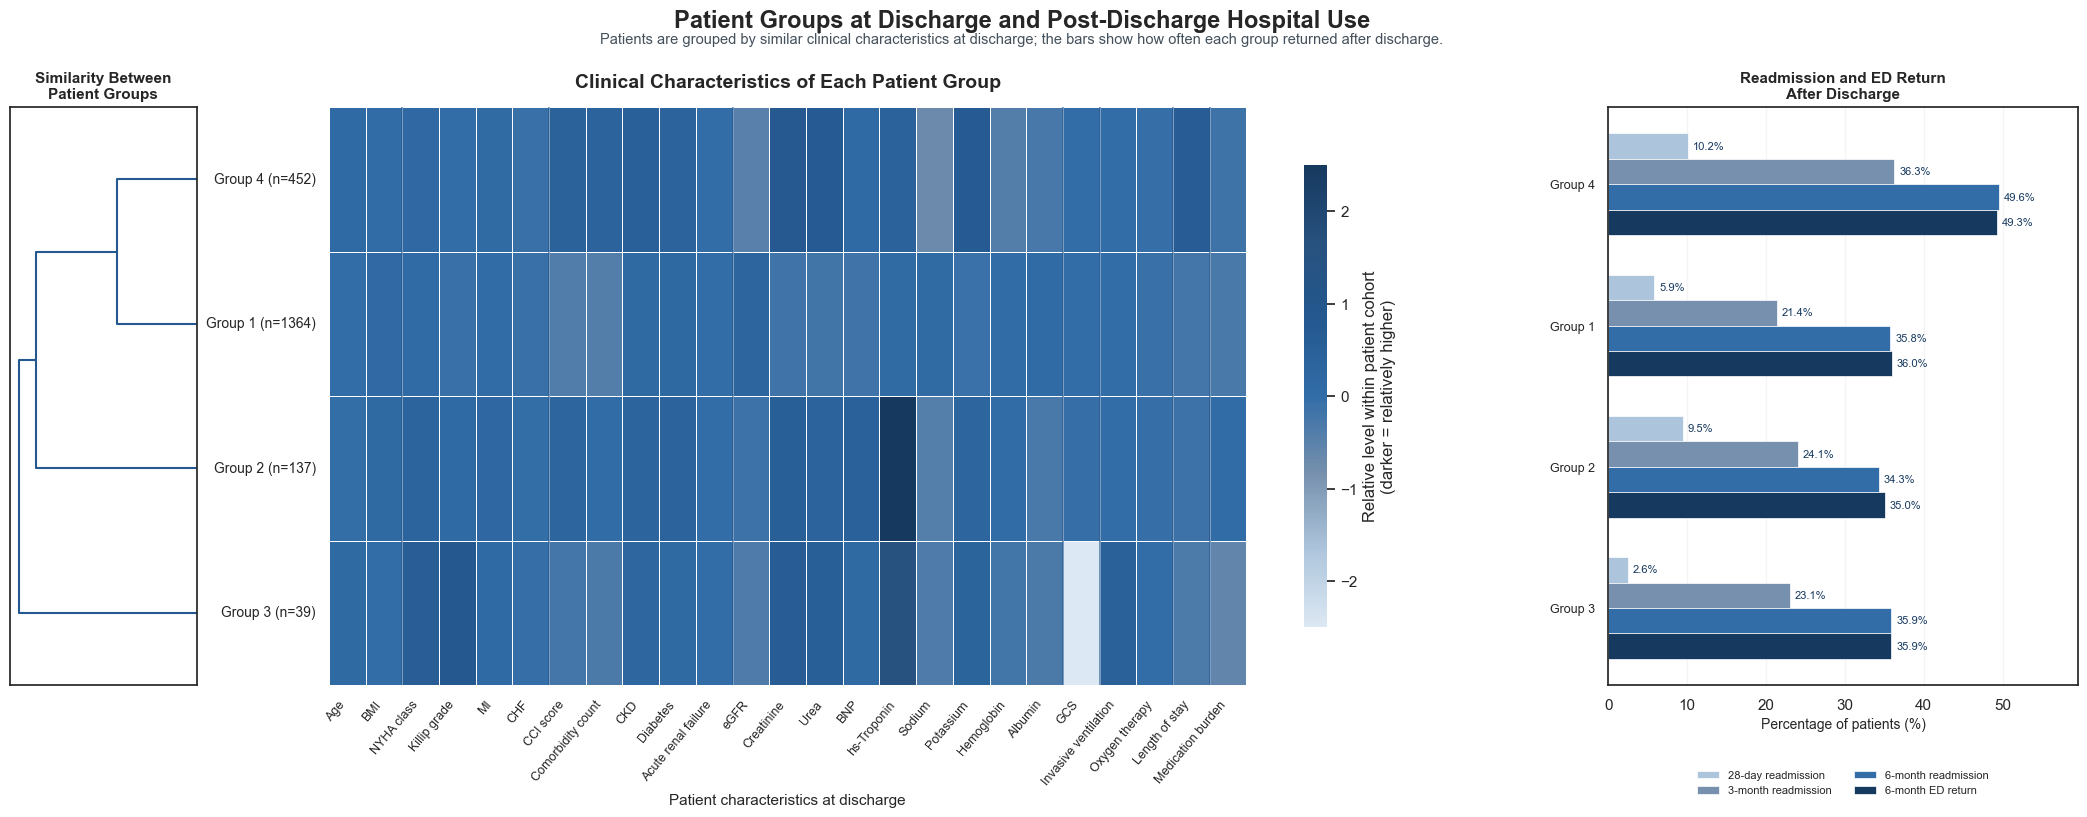

Figure saved as: Patient_Groups_Heatmap_Dendrogram.png


In [21]:

# ============================================================
# 9. CLUSTERED HEATMAP + DENDROGRAM + OUTCOME PANEL
# ============================================================

# Build robust-standardized patient-group profiles.
scaled_df = pd.DataFrame(
    X_scaled,
    columns=FEATURES,
    index=analysis_df.index
)
scaled_df["patient_group"] = analysis_df["patient_group"].values

profile_matrix = (
    scaled_df
    .groupby("patient_group")[FEATURES]
    .mean()
)

# Use group-level clinical profiles to create the dendrogram.
profile_linkage = linkage(
    profile_matrix.values,
    method="ward",
    metric="euclidean"
)

# Get the dendrogram order.
# For a left-oriented dendrogram, scipy returns leaves bottom-to-top,
# so we reverse the order for top-to-bottom display in the heatmap.
dendro_info = dendrogram(
    profile_linkage,
    labels=[f"Group {i}" for i in profile_matrix.index],
    orientation="left",
    no_plot=True
)

bottom_to_top_clusters = [
    int(label.split()[-1]) for label in dendro_info["ivl"]
]
display_clusters = bottom_to_top_clusters[::-1]

# Heatmap data in the same top-to-bottom order as the plotted dendrogram.
profile_plot = profile_matrix.loc[display_clusters].copy()
profile_plot.columns = [DISPLAY_LABELS[c] for c in profile_plot.columns]
profile_plot.index = [
    f"Group {cluster} (n={int(summary.loc[cluster, 'n'])})"
    for cluster in display_clusters
]

# Outcome panel in the same group order.
outcome_plot = (
    summary.loc[
        display_clusters,
        ["readmit_28d", "readmit_3m", "readmit_6m", "ed_6m"]
    ]
    * 100
)

outcome_plot.columns = [
    "28-day readmission",
    "3-month readmission",
    "6-month readmission",
    "6-month ED return"
]

# ------------------------------------------------------------
# COLOR PALETTES
# ------------------------------------------------------------

# Muted clinical blue palette for the heatmap.
clinical_blues = LinearSegmentedColormap.from_list(
    "clinical_blues",
    [
        "#DCE8F3",   # very light muted blue
        "#ADC5DC",   # light steel blue
        "#7690AD",   # soft blue-gray
        "#326DA7",   # medium clinical blue
        "#24588F",   # darker clinical blue
        "#27517E",   # deep slate blue
        "#16395F"    # dark navy
    ]
)

# Matching shades for the outcome bars.
# Lighter to darker shades make the time progression easier to follow.
outcome_colors = [
    "#ADC5DC",   # 28-day readmission
    "#7690AD",   # 3-month readmission
    "#326DA7",   # 6-month readmission
    "#16395F"    # 6-month ED return
]

# ------------------------------------------------------------
# FIGURE LAYOUT
# ------------------------------------------------------------

fig = plt.figure(figsize=(22, 8.5))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1.35, 8.3, 3.4],
    wspace=0.22
)

# ------------------------------------------------------------
# LEFT: DENDROGRAM
# ------------------------------------------------------------

ax_d = fig.add_subplot(gs[0, 0])

dendrogram(
    profile_linkage,
    orientation="left",
    no_labels=True,                     # avoids duplicate/overlapping labels
    color_threshold=0,
    above_threshold_color="#24588F",
    ax=ax_d
)

ax_d.set_title(
    "Similarity Between\nPatient Groups",
    fontsize=11,
    weight="bold"
)
ax_d.set_xlabel("")
ax_d.set_ylabel("")
ax_d.tick_params(axis="x", bottom=False, labelbottom=False)
ax_d.tick_params(axis="y", left=False, labelleft=False)

# ------------------------------------------------------------
# MIDDLE: HEATMAP
# ------------------------------------------------------------

ax_h = fig.add_subplot(gs[0, 1])

sns.heatmap(
    profile_plot,
    cmap=clinical_blues,
    center=0,
    vmin=-2.5,
    vmax=2.5,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Relative level within patient cohort\n(darker = relatively higher)",
        "shrink": 0.80
    },
    ax=ax_h
)

ax_h.set_title(
    "Clinical Characteristics of Each Patient Group",
    fontsize=14,
    weight="bold",
    pad=14
)

ax_h.set_xlabel(
    "Patient characteristics at discharge",
    fontsize=11
)
ax_h.set_ylabel("")

ax_h.tick_params(
    axis="x",
    labelrotation=50,
    labelsize=9
)

# Right-align x-axis labels for easier reading.
for label in ax_h.get_xticklabels():
    label.set_horizontalalignment("right")

ax_h.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=10
)

# Add visual separators between clinical domains.
# Demographics 2 | Cardiac 4 | Comorbidity 5 | Labs 9 |
# Neurologic 1 | Respiratory 2 | Hospital course 1 | Medication 1
domain_breaks = [2, 6, 11, 20, 21, 23, 24]

for x in domain_breaks:
    ax_h.axvline(
        x,
        linewidth=1.2,
        color="#24588F",
        alpha=0.70
    )

# ------------------------------------------------------------
# RIGHT: POST-DISCHARGE OUTCOME PANEL
# ------------------------------------------------------------

ax_o = fig.add_subplot(gs[0, 2])

y = np.arange(len(display_clusters))
bar_height = 0.18

for j, col in enumerate(outcome_plot.columns):
    bars = ax_o.barh(
        y + (j - 1.5) * bar_height,
        outcome_plot[col].values,
        height=bar_height,
        label=col,
        color=outcome_colors[j],
        edgecolor="white",
        linewidth=0.5
    )

    # Add percentage values at the end of each bar.
    for bar in bars:
        width = bar.get_width()
        ax_o.text(
            width + 0.6,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=8,
            color="#16395F"
        )

ax_o.set_yticks(y)

ax_o.set_yticklabels(
    [f"Group {c}" for c in display_clusters],
    fontsize=9
)

# Make Group 1st row appear at the top, matching the heatmap order.
ax_o.invert_yaxis()

ax_o.set_xlabel(
    "Percentage of patients (%)",
    fontsize=10
)

ax_o.set_title(
    "Readmission and ED Return\nAfter Discharge",
    fontsize=11,
    weight="bold"
)

# Leave a little extra room for the percentage labels.
max_outcome = outcome_plot.to_numpy().max()
ax_o.set_xlim(0, min(100, max_outcome + 10))

ax_o.grid(
    axis="x",
    alpha=0.20
)

# Put the legend below the plot so it does not cover any bars.
ax_o.legend(
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    frameon=False
)

# ------------------------------------------------------------
# OVERALL TITLE + EXPLANATORY SUBTITLE
# ------------------------------------------------------------

fig.suptitle(
    "Patient Groups at Discharge and Post-Discharge Hospital Use",
    fontsize=17,
    weight="bold",
    y=0.995
)

fig.text(
    0.5,
    0.955,
    "Patients are grouped by similar clinical characteristics at discharge; "
    "the bars show how often each group returned after discharge.",
    ha="center",
    fontsize=10.5,
    color="#44515C"
)

# Manual spacing works better than tight_layout for this multi-panel figure.
fig.subplots_adjust(
    left=0.04,
    right=0.98,
    top=0.88,
    bottom=0.20,
    wspace=0.22
)

OUTPUT_FIGURE = "Patient_Groups_Heatmap_Dendrogram.png"

plt.savefig(
    OUTPUT_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved as: {OUTPUT_FIGURE}")


### Actual Insight
The analysis identified four patient groups with distinct clinical characteristics and post-discharge outcomes. Group 4 (452 patients) showed the highest hospital utilization, with 49.6% readmitted and 49.3% returning to the emergency department within six months. This group was characterized by greater comorbidity burden, reduced kidney function, and longer hospital stays. In comparison, Groups 1, 2, and 3 had approximately 34–36% six-month readmission rates. These findings suggest that patients with multiple comorbidities, renal impairment, and prolonged hospitalization may benefit from enhanced discharge planning, medication review, closer clinical monitoring, and earlier post-discharge follow-up.